In [34]:
from langchain_groq import ChatGroq

In [35]:
llm=ChatGroq(model="qwen/qwen3-32b")

In [36]:
llm.invoke("Good morning, how are you?").content

'<think>\nOkay, the user greeted me with a cheerful "Good morning", so I should respond with a friendly greeting. Since they asked "how are you?", I need to express my current state, but since I don\'t have real emotions, I should be honest about that to establish trust.\n\nThe user might want to start a conversation, so I should ask if they need assistance and remain open. I should keep it friendly and approachable while being concise and avoiding overly complex language. I\'ll make sure to encourage them to say anything on their mind so they feel comfortable to talk further.\n\nLet me make sure the tone is warm and inviting, showing enthusiasm to help them with whatever they need. I\'ll also keep it casual since it\'s morning and they might be looking for a relaxed conversation. Double-checking for clarity and correctness in the response.\n</think>\n\nGood morning! I\'m all set to help you with anything you need. 😊 How can I assist you today? Just let me know what\'s on your mind!'

In [109]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.graph.message import add_messages
from typing import Annotated, Literal, TypedDict

In [38]:
from langchain.tools import tool
from langchain_core.messages import HumanMessage

In [39]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode

In [41]:
# Previous call_model code (reference)
# def call_model(state: MessagesState):
#     messages = state['messages']
#     response = llm.invoke(messages)
#     return {'messages': [response]}

In [40]:
import re
from langchain_core.messages import AIMessage

def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)

    # Remove model reasoning tags from visible assistant output
    if isinstance(response.content, str):
        cleaned_content = re.sub(
            r"<think>.*?</think>\s*",
            "",
            response.content,
            flags=re.DOTALL,
        ).strip()
        response = AIMessage(
            content=cleaned_content,
            additional_kwargs=response.additional_kwargs,
            response_metadata=response.response_metadata,
            id=response.id,
            tool_calls=response.tool_calls,
            invalid_tool_calls=response.invalid_tool_calls,
        )

    return {'messages': [response]}

In [31]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",call_model)
workflow.add_edge(START,"chatbot")
workflow.add_edge("chatbot",END)
app=workflow.compile()

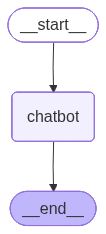

In [16]:
app

In [17]:
input={'messages':['Hi, My name is Harry']}

In [78]:
app.invoke(input)

{'messages': [HumanMessage(content='Hi, My name is Harry', additional_kwargs={}, response_metadata={}, id='bec07432-0a97-42ed-a17a-659f38bea882'),
  AIMessage(content='Hi Harry! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, let\'s see. The user wrote, "Hi, My name is Harry." They\'re introducing themselves. I need to respond appropriately. Since they mentioned their name, I should acknowledge it and offer help. Maybe say something like, "Hi Harry! How can I assist you today?" No need to use any tools here because it\'s just a greeting. Keep it friendly and open-ended. Let me make sure there\'s no hidden request in their message. Nope, just a simple introduction. So a straightforward reply should be fine.\n'}, response_metadata={'token_usage': {'completion_tokens': 123, 'prompt_tokens': 150, 'total_tokens': 273, 'completion_time': 0.226983951, 'completion_tokens_details': {'reasoning_tokens': 108}, 'prompt_time': 0.005920417, 'prompt_tokens_details': None,

In [42]:
for output in app.stream(input):
    for key, value in output.items():
        print(f"Output from {key} Node")
        print("_______")
        print(value)
        print("\n")

Output from chatbot Node
_______
{'messages': [AIMessage(content='Hi Harry! Nice to meet you! 😊 How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 14, 'total_tokens': 125, 'completion_time': 0.228144228, 'completion_tokens_details': None, 'prompt_time': 0.000339174, 'prompt_tokens_details': None, 'queue_time': 0.048694416, 'total_time': 0.228483402}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d193b-f39d-7823-824a-8cf5269f885b-0', tool_calls=[], invalid_tool_calls=[])]}




# Adding Tools to chatbot

In [43]:
@tool
def search(query: str):
    """this is my custom tool"""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degreees and foggy."
    return "It's sunny and 75 degrees."

In [44]:
search.invoke('What is temperature in San Francisco?')

"It's 60 degreees and foggy."

In [46]:
search.invoke("what's the weather in India?")

"It's sunny and 75 degrees."

In [47]:
tools=[search]

In [48]:
tools_node=ToolNode(tools)

In [49]:
tools_node

tools(tags=None, recurse=True, explode_args=False, func_accepts={'config': ('N/A', <class 'inspect._empty'>), 'runtime': ('N/A', <class 'inspect._empty'>)}, _tools_by_name={'search': StructuredTool(name='search', description='this is my custom tool', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x00000271B56B74C0>)}, _injected_args={'search': _InjectedArgs(state={}, store=None, runtime=None)}, _handle_tool_errors=<function _default_handle_tool_errors at 0x00000271B3B091C0>, _messages_key='messages', _wrap_tool_call=None, _awrap_tool_call=None)

In [50]:
# binding llm with tools node
llm_with_tools=llm.bind_tools(tools)

In [51]:
llm_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x00000271B32C2710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000271B3BB0190>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'search', 'description': 'this is my custom tool', 'parameters': {'properties': {'query': {'type': 'string'}}, 'required': ['query'], 'type': 'object'}}}]}, config={}, config_factories=[])

In [52]:
import re
from langchain_core.messages import AIMessage

def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)

    # Remove model reasoning tags from visible assistant output
    if isinstance(response.content, str):
        cleaned_content = re.sub(
            r"<think>.*?</think>\s*",
            "",
            response.content,
            flags=re.DOTALL,
        ).strip()
        response = AIMessage(
            content=cleaned_content,
            additional_kwargs=response.additional_kwargs,
            response_metadata=response.response_metadata,
            id=response.id,
            tool_calls=response.tool_calls,
            invalid_tool_calls=response.invalid_tool_calls,
        )

    return {'messages': [response]}

In [53]:
response=call_model({'messages':['hi how are you?']})

In [54]:
response

{'messages': [AIMessage(content='Hi! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user asked "hi how are you?" So I need to respond appropriately. Since the user is greeting me, I should respond with a friendly greeting. Let me check if there\'s any function I need to call here. The available tool is the search function, which requires a query parameter. But the user\'s message is just a greeting, not a search query. So I don\'t need to use the search function here. I should just reply with a standard greeting response. Let me make sure there\'s no hidden request in their message. Nope, it\'s just a simple "hi how are you?" So I\'ll respond with something like "Hi! How can I assist you today?" to be polite and offer help.\n'}, response_metadata={'token_usage': {'completion_tokens': 162, 'prompt_tokens': 149, 'total_tokens': 311, 'completion_time': 0.305239033, 'completion_tokens_details': {'reasoning_tokens': 148}, 'prompt_time': 0.006051557, 'prompt

In [55]:
messages=response['messages']

In [60]:
messages

[AIMessage(content='Hi! How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user asked "hi how are you?" So I need to respond appropriately. Since the user is greeting me, I should respond with a friendly greeting. Let me check if there\'s any function I need to call here. The available tool is the search function, which requires a query parameter. But the user\'s message is just a greeting, not a search query. So I don\'t need to use the search function here. I should just reply with a standard greeting response. Let me make sure there\'s no hidden request in their message. Nope, it\'s just a simple "hi how are you?" So I\'ll respond with something like "Hi! How can I assist you today?" to be polite and offer help.\n'}, response_metadata={'token_usage': {'completion_tokens': 162, 'prompt_tokens': 149, 'total_tokens': 311, 'completion_time': 0.305239033, 'completion_tokens_details': {'reasoning_tokens': 148}, 'prompt_time': 0.006051557, 'prompt_tokens_detai

In [58]:
last_message=messages[-1]

In [61]:
last_message.tool_calls

[]

In [63]:
response=call_model({'messages':['What is the weather in India?']})

In [64]:
response

{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in India. Let me check the tools available. There\'s a search function that takes a query parameter. Since India is a large country with varying weather across different regions, I should use the search tool to get the most current and accurate information. I\'ll call the search function with the query "current weather in India" to retrieve the latest weather data.\n', 'tool_calls': [{'id': '62f7yzyj5', 'function': {'arguments': '{"query":"current weather in India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 106, 'prompt_tokens': 151, 'total_tokens': 257, 'completion_time': 0.183402035, 'completion_tokens_details': {'reasoning_tokens': 80}, 'prompt_time': 0.006291333, 'prompt_tokens_details': None, 'queue_time': 0.046463816, 'total_time': 0.189693368}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf9

In [67]:
messages=response['messages']

In [68]:
last_message=messages[-1]

In [69]:
last_message.tool_calls

[{'name': 'search',
  'args': {'query': 'current weather in India'},
  'id': '62f7yzyj5',
  'type': 'tool_call'}]

In [76]:
# Creating a router function to decide whether to call tools or not based on the model response
def router_function(state: MessagesState):
    last_message = state['messages'][-1]
    if last_message.tool_calls:  # if tools were called, route to tools node
        return 'tools'
    return END

In [ ]:
# defining a new graph

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tools_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", router_function, {'tools': "tools", END: END})


app = workflow.compile()

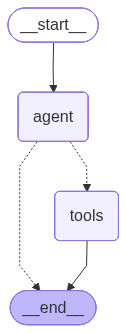

In [81]:
app

In [82]:
app.invoke({'messages': ['Hi, Who are you?']})

{'messages': [HumanMessage(content='Hi, Who are you?', additional_kwargs={}, response_metadata={}, id='65ad85bc-efd9-4801-95b6-0e6dc8779772'),
  AIMessage(content='I am Qwen, a large-scale language model developed by Alibaba Cloud. I am designed to assist with a wide range of tasks, including answering questions, writing stories, composing emails, creating scripts, performing logical reasoning, coding, and more. How can I assist you today?', additional_kwargs={'reasoning_content': 'Okay, the user asked, "Hi, Who are you?" I need to respond appropriately. Let me check the tools provided. The only tool available is the search function, which requires a query parameter. But the user\'s question is a general inquiry about my identity. Since there\'s no specific function to provide my introduction, I should answer directly without using the tool. I\'ll explain that I\'m an AI assistant developed by Alibaba Cloud and mention my capabilities. No need to call the search function here because t

In [83]:
app.invoke({'messages': ['Hi, what is the weather in San Francisco?']})

{'messages': [HumanMessage(content='Hi, what is the weather in San Francisco?', additional_kwargs={}, response_metadata={}, id='eec00c26-1b4b-4abc-aa1c-033d76de2521'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in San Francisco. Let me check the tools available. There\'s a function called "search" with a parameter "query". I need to use that to get the weather information. The query should be a string, so I\'ll format it as "weather in San Francisco". I\'ll make sure to call the function correctly with the right parameters. That\'s all I need to do here.\n', 'tool_calls': [{'id': 'wew4gvgt0', 'function': {'arguments': '{"query":"weather in San Francisco"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 154, 'total_tokens': 267, 'completion_time': 0.190970619, 'completion_tokens_details': {'reasoning_tokens': 87}, 'prompt_time': 0.006091965, 'prompt_

In [ ]:
# defining a new graph where the tool output is fed back to the agent node

workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tools_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", router_function, {'tools': "tools", END: END})
workflow.add_edge("tools", "agent")

app = workflow.compile()

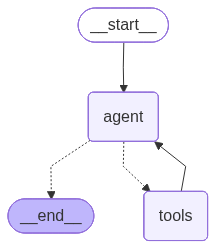

In [85]:
app

In [87]:
for output in app.stream({'messages': ['Hi, what is the weather in sf?']}):
    for key, value in output.items():
        print(f"Output from {key} Node")
        print("______________")
        print(value)
        print("\n")

Output from agent Node
______________
{'messages': [AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in San Francisco. I need to figure out which tool to use. The available tool is called "search" and it takes a "query" parameter. Since there\'s no specific weather function, using the search tool makes sense. I\'ll structure the query to get the current weather in SF. Let me make sure the parameters are correct. The query should be a string, so "current weather in San Francisco" would work. I\'ll format the tool call accordingly.\n', 'tool_calls': [{'id': 'ev4q670v3', 'function': {'arguments': '{"query":"current weather in San Francisco"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 130, 'prompt_tokens': 153, 'total_tokens': 283, 'completion_time': 0.236905342, 'completion_tokens_details': {'reasoning_tokens': 103}, 'prompt_time': 0.006470548, 'prompt_tokens_details': None, 'qu

In [86]:
app.invoke({'messages': ['Hi, what is the weather in San Francisco?']})

{'messages': [HumanMessage(content='Hi, what is the weather in San Francisco?', additional_kwargs={}, response_metadata={}, id='a8eb39bb-38b5-4dfb-9abd-e51ae53d11c7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking about the weather in San Francisco. Let me check the tools provided. There\'s a function called "search" with a parameter "query". The description says it\'s a custom tool. Since I don\'t have a specific weather function, I should use the search function to look up the current weather. I\'ll format the query parameter as "current weather in San Francisco" to get the most relevant results. Make sure to structure the tool call correctly within the XML tags.\n', 'tool_calls': [{'id': '2dyepbks2', 'function': {'arguments': '{"query":"current weather in San Francisco"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 154, 'total_tokens': 281, 'completion_time': 0.23

In [88]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [91]:
# defining a new graph

workflow3 = StateGraph(MessagesState)
workflow3.add_node("agent", call_model)
workflow3.add_node("tools", tools_node)

workflow3.add_edge(START, "agent")
workflow3.add_conditional_edges("agent", router_function, {'tools': "tools", END: END})
workflow3.add_edge("tools", "agent")

app = workflow3.compile()

In [93]:
app3=workflow3.compile(checkpointer=memory)

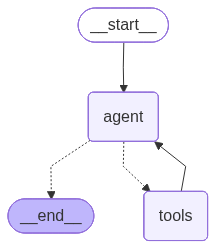

In [94]:
app

In [96]:
config={'configurable':{'thread_id': '1'}}

In [97]:
events=app3.stream(
    {'messages':['Hi there! My name is Harry.']},
    config=config,
    stream_mode="values"
)

In [98]:
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Harry.
================================== Ai Message ==================================

Hello Harry! Welcome to the chat. How can I assist you today?


In [100]:
events=app3.stream(
    {'messages':['What is the weather in India?']},
    config=config,
    stream_mode="values"
)

In [101]:
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

What is the weather in India?
================================== Ai Message ==================================
Tool Calls:
  search (3yw5s8zgp)
 Call ID: 3yw5s8zgp
  Args:
    query: current weather in India
================================= Tool Message =================================
Name: search

It's sunny and 75 degrees.
================================== Ai Message ==================================

The current weather in India is sunny with a temperature of 75°C. Let me know if you need more details!


In [102]:
events=app3.stream(
    {'messages':['What is my name?']},
    config=config,
    stream_mode="values"
)

In [103]:
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Harry, as you mentioned earlier. How can I assist you today?


In [104]:
events=app3.stream(
    {'messages':['Summary of our conversation so far?']},
    config=config,
    stream_mode="values"
)

In [105]:
for event in events:
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Summary of our conversation so far?
================================== Ai Message ==================================

Here's a summary of our conversation so far:

1. **Introduction**: You introduced yourself as Harry.  
2. **Weather Inquiry**: You asked about the weather in India, and I provided an update (sunny and 75°C).  
3. **Name Confirmation**: You asked, "What is my name?" and I reminded you it's Harry.  

Let me know if you'd like to continue or need further assistance! 😊


In [108]:
memory.get(config)

{'v': 4,
 'ts': '2026-03-23T08:16:00.109542+00:00',
 'id': '1f126908-6a1d-67a0-800c-8e85844df19e',
 'channel_versions': {'__start__': '00000000000000000000000000000013.0.42399791034620216',
  'messages': '00000000000000000000000000000014.0.4242070935089578',
  'branch:to:agent': '00000000000000000000000000000014.0.4242070935089578',
  'branch:to:tools': '00000000000000000000000000000007.0.49287584188564304'},
 'versions_seen': {'__input__': {},
  '__start__': {'__start__': '00000000000000000000000000000012.0.4508865790829908'},
  'agent': {'branch:to:agent': '00000000000000000000000000000013.0.42399791034620216'},
  'tools': {'branch:to:tools': '00000000000000000000000000000006.0.13323392246639287'}},
 'updated_channels': ['messages'],
 'channel_values': {'messages': [HumanMessage(content='Hi there! My name is Harry.', additional_kwargs={}, response_metadata={}, id='56396569-f0b3-475b-bcf0-c438380de894'),
   AIMessage(content='Hello Harry! Welcome to the chat. How can I assist you toda